# ¡Hola Franshelly! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


-----

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Franshelly, has hecho un trabajo muy completo y organizado en todas las etapas del proyecto: desde la exploración inicial hasta el análisis estadístico y las visualizaciones, cada paso está bien fundamentado y ejecutado con precisión. Se nota que comprendiste el flujo del análisis y aplicaste correctamente herramientas como `groupby`, `merge` y pruebas estadísticas, lo cual le da solidez a tu trabajo.

Como sugerencia para seguir mejorando, sería valioso que complementes tu análisis con una prueba de Levene antes de aplicar la t de Student, y que fortalezcas tus conclusiones enfocándote más en los hallazgos y su impacto para el negocio. 

Ten en cuenta estas recomendaciones, te serán muy útiles en futuros análisis

Éxitos en tu próximo Sprint 🚀

*Estado del Proyecto:* **Aprobado**

</div>

-----

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [2]:
# Cargar todas las librerías
from scipy import stats as st
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns


## Cargar datos

In [3]:
# Carga los archivos de datos en diferentes DataFrames

calls = pd.read_csv('/datasets/megaline_calls.csv',sep=',')
internet = pd.read_csv('/datasets/megaline_internet.csv',sep=',')
messages = pd.read_csv('/datasets/megaline_messages.csv',sep=',')
plans = pd.read_csv('/datasets/megaline_plans.csv',sep=',')
users = pd.read_csv('/datasets/megaline_users.csv',sep=',')


## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [4]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

plans.info()
display(plans)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [5]:
# Imprime una muestra de los datos para las tarifas
plans.head(10)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


El DataFrame contiene datos de tipo string, enteros y flotantes, además de valores nulos. En la columna mb_per_month_included, los datos están en MB sin redondear; se convertirán a GB, redondeando los valores, y se renombrará la columna con el método rename.

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [6]:
plans['mb_per_month_included']= plans['mb_per_month_included']/1024

plans = plans.rename(columns={'mb_per_month_included':'gb_per_month'})

plans.head()



,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

los datos se encuentra con un tipo de de datos correctos y ya se hicieron todas las correciones necesarias, no se encuentran factores o datos adicionales para agregar.

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()
display(users)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN


In [8]:
# Imprime una muestra de datos para usuarios
users.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaN
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaN
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaN
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaN


El DataFrame contiene datos de tipo string, enteros, flotantes y valores nulos. Las columnas reg_date y churn_date están como tipo object, por lo que se convertirán a tipo fecha con el metodo pd.to_datetime().

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [9]:
users['reg_date']= pd.to_datetime(users['reg_date'], format='%Y-%m-%d')

users['churn_date']= pd.to_datetime(users['churn_date'], format='%Y-%m-%d')

users.info()
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [10]:
users['month']= users['reg_date'].dt.month
users.head(10)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,12
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,1
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,5
5,1005,Livia,Shields,31,"Dallas-Fort Worth-Arlington, TX MSA",2018-11-29,surf,NaT,11
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18,11
7,1007,Eusebio,Welch,42,"Grand Rapids-Kentwood, MI MSA",2018-07-11,surf,NaT,7
8,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,ultimate,NaT,8
9,1009,Gerry,Little,19,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-22,surf,NaT,4


## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()
display(calls)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72
137731,1499_200,1499,2018-10-20,10.89
137732,1499_201,1499,2018-09-21,8.12
137733,1499_202,1499,2018-10-10,0.37


In [12]:
# Imprime una muestra de datos para las llamadas
calls.head(10)


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
5,1000_388,1000,2018-12-31,2.20
6,1000_510,1000,2018-12-27,5.75
7,1000_521,1000,2018-12-28,14.18
8,1000_530,1000,2018-12-28,5.77
9,1000_544,1000,2018-12-26,4.40


### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [13]:
calls['call_date']= pd.to_datetime(calls['call_date'], format='%Y-%m-%d')

calls['id']= calls['id'].astype(int)

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  int64         
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 4.2 MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [14]:
calls['month']= calls['call_date'].dt.month
calls.head(10)


,id,user_id,call_date,duration,month
0,100093,1000,2018-12-27,8.52,12
1,1000145,1000,2018-12-27,13.66,12
2,1000247,1000,2018-12-27,14.48,12
3,1000309,1000,2018-12-28,5.76,12
4,1000380,1000,2018-12-30,4.22,12
5,1000388,1000,2018-12-31,2.20,12
6,1000510,1000,2018-12-27,5.75,12
7,1000521,1000,2018-12-28,14.18,12
8,1000530,1000,2018-12-28,5.77,12
9,1000544,1000,2018-12-26,4.40,12


In [15]:
calls.head(10)

,id,user_id,call_date,duration,month
0,100093,1000,2018-12-27,8.52,12
1,1000145,1000,2018-12-27,13.66,12
2,1000247,1000,2018-12-27,14.48,12
3,1000309,1000,2018-12-28,5.76,12
4,1000380,1000,2018-12-30,4.22,12
5,1000388,1000,2018-12-31,2.20,12
6,1000510,1000,2018-12-27,5.75,12
7,1000521,1000,2018-12-28,14.18,12
8,1000530,1000,2018-12-28,5.77,12
9,1000544,1000,2018-12-26,4.40,12


## Mensajes

In [16]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

messages.info()
display(messages)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
...,...,...,...
76046,1497_526,1497,2018-12-24
76047,1497_536,1497,2018-12-24
76048,1497_547,1497,2018-12-31
76049,1497_558,1497,2018-12-24


In [17]:
# Imprime una muestra de datos para los mensajes
messages.head(10)


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
5,1000_346,1000,2018-12-29
6,1000_386,1000,2018-12-30
7,1000_413,1000,2018-12-31
8,1000_502,1000,2018-12-27
9,1000_525,1000,2018-12-28


El DataFrame contiene datos de tipo  enteros, flotantes y valores nulos. Las columna message_date están como tipo object, por lo que se convertirán a tipo fecha con el metodo pd.to_datetime(), la culumna Id esta en tipo object por lo que se convertira a entero con el metodo astype().

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [18]:
messages['message_date']= pd.to_datetime(messages['message_date'], format='%Y-%m-%d')

messages['id']= messages['id'].astype(int)

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  int64         
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.7 MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [19]:
messages['month']=messages['message_date'].dt.month
messages.head(10)

,id,user_id,message_date,month
0,1000125,1000,2018-12-27,12
1,1000160,1000,2018-12-31,12
2,1000223,1000,2018-12-31,12
3,1000251,1000,2018-12-27,12
4,1000255,1000,2018-12-26,12
5,1000346,1000,2018-12-29,12
6,1000386,1000,2018-12-30,12
7,1000413,1000,2018-12-31,12
8,1000502,1000,2018-12-27,12
9,1000525,1000,2018-12-28,12


## Internet

In [20]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()
display(internet)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06
104821,1499_216,1499,2018-12-30,304.72
104822,1499_217,1499,2018-09-22,292.75
104823,1499_218,1499,2018-12-07,0.00


In [21]:
# Imprime una muestra de datos para el tráfico de internet
internet.head(10)


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
5,1001_0,1001,2018-08-24,284.68
6,1001_3,1001,2018-12-09,656.04
7,1001_4,1001,2018-11-04,16.97
8,1001_10,1001,2018-11-27,135.18
9,1001_15,1001,2018-12-13,761.92


El DataFrame contiene datos de tipo  enteros, flotantes y valores nulos. La columna session_date están como tipo object, por lo que se convertirán a tipo fecha con el metodo pd.to_datetime(), la culumna Id esta en tipo object por lo que se convertira a entero con el metodo astype().

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [22]:
internet['session_date']= pd.to_datetime(internet['session_date'], format='%Y-%m-%d')
internet['id']= internet['id'].astype(int)
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  int64         
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 2.3 MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [23]:
internet['month']= internet['session_date'].dt.month
internet.head(10)

,id,user_id,session_date,mb_used,month
0,100013,1000,2018-12-29,89.86,12
1,1000204,1000,2018-12-31,0.00,12
2,1000379,1000,2018-12-28,660.40,12
3,1000413,1000,2018-12-26,270.99,12
4,1000442,1000,2018-12-27,880.22,12
5,10010,1001,2018-08-24,284.68,8
6,10013,1001,2018-12-09,656.04,12
7,10014,1001,2018-11-04,16.97,11
8,100110,1001,2018-11-27,135.18,11
9,100115,1001,2018-12-13,761.92,12


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Excelente trabajo en el análisis preliminar de los datasets. Usaste correctamente las funciones `info` y `head` para revisar la estructura y el contenido de los datos, lo que te permitió realizar los ajustes necesarios. Esto facilitará el análisis de los datos y el desarrollo de las demás etapas del proyecto.


</div>

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [24]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

plans.info()
display(plans)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   messages_included  2 non-null      int64  
 1   gb_per_month       2 non-null      float64
 2   minutes_included   2 non-null      int64  
 3   usd_monthly_pay    2 non-null      int64  
 4   usd_per_gb         2 non-null      int64  
 5   usd_per_message    2 non-null      float64
 6   usd_per_minute     2 non-null      float64
 7   plan_name          2 non-null      object 
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [25]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

total_minutes = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()
total_minutes.rename(columns={'duration': 'minutes_used'}, inplace=True)

total_minutes.head(5)


,user_id,month,minutes_used
0,1000,12,116.83
1,1001,8,171.14
2,1001,9,297.69
3,1001,10,374.11
4,1001,11,404.59


In [26]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

call_counts = calls.groupby(['user_id', 'month'])['duration'].count().reset_index()
call_counts.rename(columns={'duration': 'calls_made'}, inplace=True)

#Unir ambos resultados
month_calls = pd.merge(total_minutes, call_counts, on=['user_id', 'month'])

month_calls.head(3)




,user_id,month,minutes_used,calls_made
0,1000,12,116.83,16
1,1001,8,171.14,27
2,1001,9,297.69,49


In [27]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

month_mess = messages.groupby(['user_id','month'])['id'].count().reset_index()

month_mess = month_mess.rename(columns={'id':'num_mess'})


In [28]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

month_int = internet.groupby(['user_id','month'])['mb_used'].sum().reset_index()
month_int.head(5)


,user_id,month,mb_used
0,1000,12,1901.47
1,1001,8,6919.15
2,1001,9,13314.82
3,1001,10,22330.49
4,1001,11,18504.30


In [29]:
month_int['gb_used'] = (month_int['mb_used']/1024).apply(math.ceil)
month_int['gb_used'] = np.ceil(month_int['mb_used']/1024)
month_int.head(3)

,user_id,month,mb_used,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [30]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

df_monthly = month_calls.merge(month_mess, on=['user_id', 'month'],how = 'outer')
df_monthly = df_monthly.merge(month_int, on=['user_id', 'month'],how = 'outer')

df_monthly.head(5)




,user_id,month,minutes_used,calls_made,num_mess,mb_used,gb_used
0,1000,12,116.83,16.0,11.0,1901.47,2.0
1,1001,8,171.14,27.0,30.0,6919.15,7.0
2,1001,9,297.69,49.0,44.0,13314.82,14.0
3,1001,10,374.11,65.0,53.0,22330.49,22.0
4,1001,11,404.59,64.0,36.0,18504.30,19.0


In [31]:
df_monthly = month_calls.merge(month_mess, on=['user_id', 'month'],how = 'outer')
df_monthly = df_monthly.merge(month_int, on=['user_id', 'month'],how = 'outer')

df_monthly.head(5)


,user_id,month,minutes_used,calls_made,num_mess,mb_used,gb_used
0,1000,12,116.83,16.0,11.0,1901.47,2.0
1,1001,8,171.14,27.0,30.0,6919.15,7.0
2,1001,9,297.69,49.0,44.0,13314.82,14.0
3,1001,10,374.11,65.0,53.0,22330.49,22.0
4,1001,11,404.59,64.0,36.0,18504.30,19.0


In [32]:
users_1= users[['user_id','plan','city']]
plans
df_monthly.head(5)

,user_id,month,minutes_used,calls_made,num_mess,mb_used,gb_used
0,1000,12,116.83,16.0,11.0,1901.47,2.0
1,1001,8,171.14,27.0,30.0,6919.15,7.0
2,1001,9,297.69,49.0,44.0,13314.82,14.0
3,1001,10,374.11,65.0,53.0,22330.49,22.0
4,1001,11,404.59,64.0,36.0,18504.30,19.0


In [33]:
df_monthly= df_monthly.merge(users_1,on='user_id',how = 'left')
df_monthly= df_monthly.merge(plans,left_on='plan',right_on='plan_name',how='left')
df_monthly.head(5)

,user_id,month,minutes_used,calls_made,num_mess,mb_used,gb_used,plan,city,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,12,116.83,16.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30.0,3000,70,7,0.01,0.01,ultimate
1,1001,8,171.14,27.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf
2,1001,9,297.69,49.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf
3,1001,10,374.11,65.0,53.0,22330.49,22.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf
4,1001,11,404.59,64.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [34]:
# Calcula el ingreso mensual para cada usuario

def revenue(data):
    #tarifa base mensual
    tarifa_base= data['usd_monthly_pay']

    #llamdas
    exceso_minutos = max(0,data['minutes_used'] - data['minutes_included'])
    ingreso_minutos = exceso_minutos * data['usd_per_minute']

    #mensajes
    exceso_mensaje=max(0,data['num_mess'] - data['messages_included'])
    ingreso_mensaje = exceso_mensaje * data['usd_per_message']



    #datos
    exceso_datos=max(0,data['gb_used'] - data['gb_per_month'])
    ingreso_datos=exceso_datos * data['usd_per_gb']



    return tarifa_base + ingreso_minutos + ingreso_mensaje + ingreso_datos



In [35]:
#df_monthly.apply(revenue,axis=1)
df_monthly['total_ingresos'] = df_monthly.apply(revenue,axis=1)
df_monthly.head()


,user_id,month,minutes_used,calls_made,num_mess,mb_used,gb_used,plan,city,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,total_ingresos
0,1000,12,116.83,16.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",1000,30.0,3000,70,7,0.01,0.01,ultimate,70.00
1,1001,8,171.14,27.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf,20.00
2,1001,9,297.69,49.0,44.0,13314.82,14.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf,20.00
3,1001,10,374.11,65.0,53.0,22330.49,22.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf,90.09
4,1001,11,404.59,64.0,36.0,18504.30,19.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",50,15.0,500,20,10,0.03,0.03,surf,60.00


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

¡Perfecto Franshelly! Hiciste un excelente uso de las funciones `groupby`  y `merge`, logrando agrupar correctamente la información de consumo de llamadas, mensajes e internet de cada usuario por mes, inclusive considerando las condiciones de redondeo. Además, calculaste de manera precisa el cobro mensual y reflejaste los valores correctos en la columna *total_ingresos*. ¡Buen trabajo!

</div>

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

<AxesSubplot:xlabel='month'>

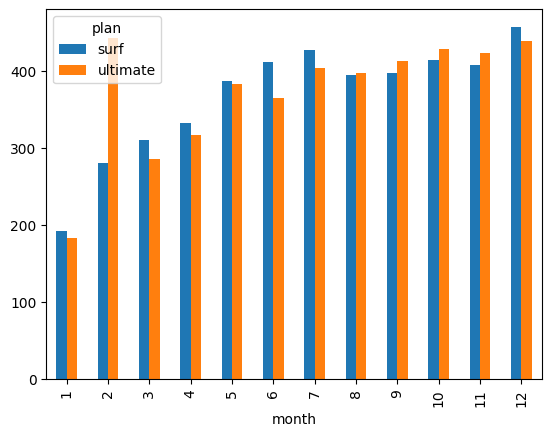

In [36]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

df_monthly.groupby(['month','plan'])['minutes_used'].mean().unstack().plot(kind='bar')


<AxesSubplot:ylabel='Frequency'>

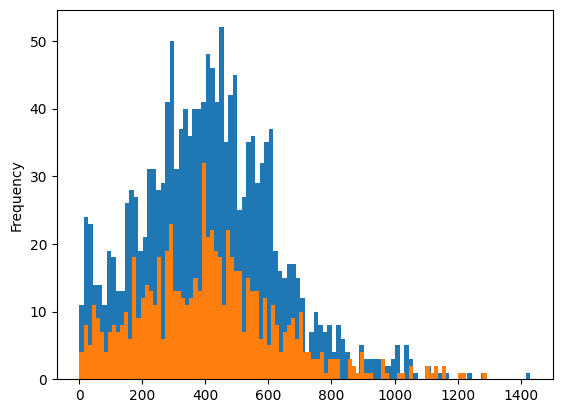

In [37]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

df_monthly[df_monthly['plan'] == "surf"]["minutes_used"].plot(kind = 'hist', bins = 100)
df_monthly[df_monthly['plan'] == "ultimate"]["minutes_used"].plot(kind = 'hist', bins = 100 )


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [38]:
# Calcula la media y la varianza de la duración mensual de llamadas.

df_monthly.groupby(['plan','month'])['minutes_used'].describe()


count        mean         std     min       25%      50%  \
plan     month                                                             
surf     1        2.0  192.840000  121.636508  106.83  149.8350  192.840   
         2        9.0  280.851111  216.700761   36.82  231.8700  240.660   
         3       23.0  310.970000  178.385308   33.43  217.7350  312.790   
         4       50.0  332.380000  213.578245   15.69  171.1125  320.120   
         5       75.0  387.108000  225.340026   15.14  205.2100  409.060   
         6       96.0  411.450625  198.554914   12.50  285.0800  407.630   
         7      120.0  428.060917  231.007663   16.06  288.1375  431.235   
         8      159.0  394.474717  215.961202    3.90  247.9750  372.560   
         9      191.0  397.133298  199.462535    1.20  252.2950  403.340   
         10     232.0  414.435733  210.008766    0.00  267.2450  410.350   
         11     277.0  408.255415  208.712422    4.60  260.7900  395.180   
         12     311.0  457.547074  231.617750   16.28  310.5350  429.190   
ultimate 1        4.0  183.162500  122.439250   14.73  131.4000  221.425   
         2        6.0  443.171667  220.407762   86.04  375.1700  443.550   
         3       12.0  285.701667  232.967631   20.63   76.3475  236.390   
         4       21.0  316.508095  176.232027   49.41  205.7100  283.540   
         5       29.0  383.664828  198.218594   21.25  250.6000  385.480   
         6       45.0  365.358222  183.950456   43.77  227.0100  377.480   
         7       59.0  403.767288  254.645689   13.95  190.2750  403.420   
         8       71.0  397.274789  218.357939   11.05  235.2600  388.240   
         9       86.0  413.287326  225.819630   16.84  236.3900  410.150   
         10     105.0  429.217238  216.983004   32.56  285.5100  431.840   
         11     126.0  423.814683  230.810826    0.00  277.9750  409.835   
         12     149.0  438.824832  232.309560    8.73  268.0500  421.420   

                     75%      max  
plan     month                     
surf     1      235.8450   278.85  
         2      287.1700   769.02  
         3      376.2800   739.05  
         4      475.4225   991.24  
         5      528.8750   995.63  
         6      525.0300   975.62  
         7      555.6325  1112.88  
         8      532.8650  1043.18  
         9      522.1450  1146.22  
         10     550.1050  1163.31  
         11     551.0700  1234.57  
         12     581.0600  1431.22  
ultimate 1      273.1875   275.07  
         2      558.0850   737.25  
         3      449.4275   663.16  
         4      424.6600   703.19  
         5      449.3600   817.68  
         6      469.0500   755.17  
         7      523.9900  1123.11  
         8      515.0550  1208.60  
         9      529.6175  1159.29  
         10     531.0800  1137.00  
         11     553.5150  1133.59  
         12     560.0800  1292.09

In [39]:
df_monthly.groupby(['plan','month'])['minutes_used'].var()

plan      month
surf      1        14795.440200
          2        46959.219961
          3        31821.317991
          4        45615.666796
          5        50778.127459
          6        39424.054023
          7        53364.540232
          8        46639.240873
          9        39785.302974
          10       44103.681803
          11       43560.874928
          12       53646.781898
ultimate  1        14991.369958
          2        48579.581537
          3        54273.917252
          4        31057.727496
          5        39290.610940
          6        33837.770156
          7        64844.426958
          8        47680.189425
          9        50994.505514
          10       47081.623851
          11       53273.637319
          12       53967.731609
Name: minutes_used, dtype: float64

<AxesSubplot:xlabel='month', ylabel='minutes_used'>

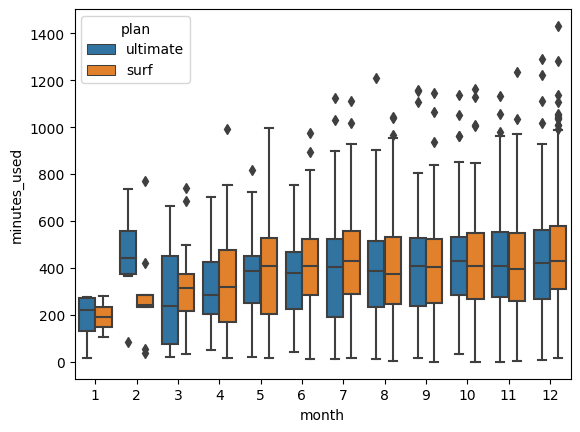

In [40]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

sns.boxplot(data= df_monthly, y='minutes_used', x='month', hue='plan')




Se observa que los usuarios del plan Surf tienden a salirse más de los rangos establecidos en comparación con los usuarios del plan Ultimate. Este comportamiento puede atribuirse a que el plan Surf incluye menos minutos, lleva a que sus usuarios excedan más fácilmente los límites establecidos en su plan. 

### Mensajes

<AxesSubplot:xlabel='month'>

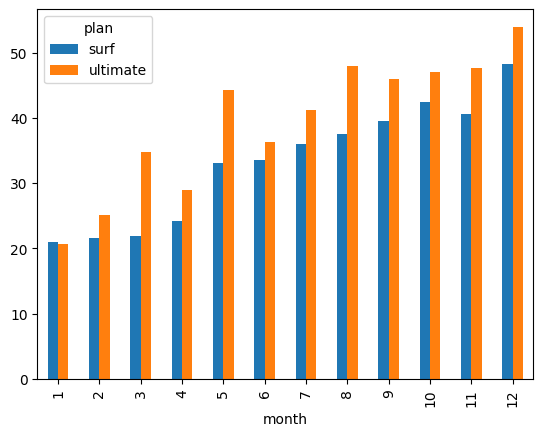

In [41]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

df_monthly.groupby(['month','plan'])['num_mess'].mean().unstack().plot(kind='bar')


In [42]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

df_monthly.groupby(['plan'])['gb_used'].mean()


plan
surf        16.831194
ultimate    17.331015
Name: gb_used, dtype: float64

Se puede notar que los usuarios del plan Ultimate envíaron más mensajes en los meses de mayo, agosto y diciembre, En cambio, en el mes de enero, fueron los usuarios del plan Surf quienes enviaron más mensajes, lo que podría indicar un mayor uso tras las festividades o al inicio del año.

### Internet

In [43]:
#los gigas utilizados en promedio por cada mes del año,diferenciados por plan

<AxesSubplot:xlabel='month'>

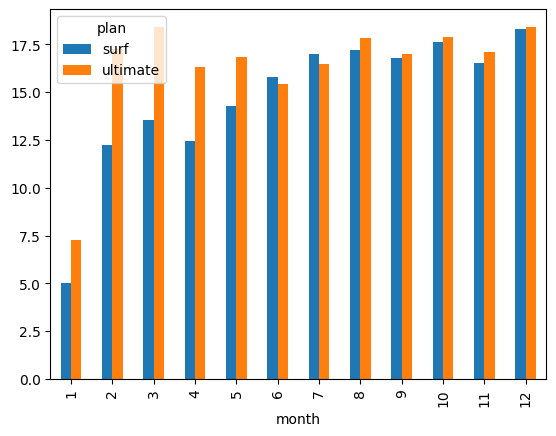

In [44]:
df_monthly.groupby(['month','plan'])['gb_used'].mean().unstack().plot(kind='bar')

In [45]:
#histograma para representar trafico mensual

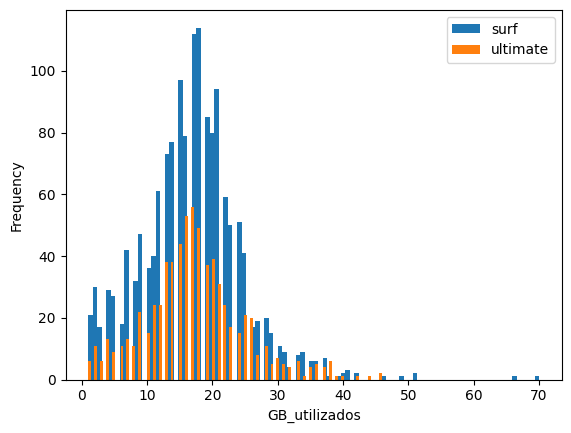

In [46]:
df_monthly [df_monthly ['plan']=='surf'] ['gb_used'].plot(kind='hist', bins = 100)

df_monthly [df_monthly ['plan']=='ultimate'] ['gb_used'].plot(kind='hist', bins = 100)

plt.xlabel ('GB_utilizados')
plt.legend(['surf','ultimate'])
plt.show()

El comportamiento de consumo de tráfico  es similar en ambos planes, pero el plan Surf muestra un mayor uso, probablemente debido a que tiene más usuarios que el plan Ultimate.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

<AxesSubplot:xlabel='month'>

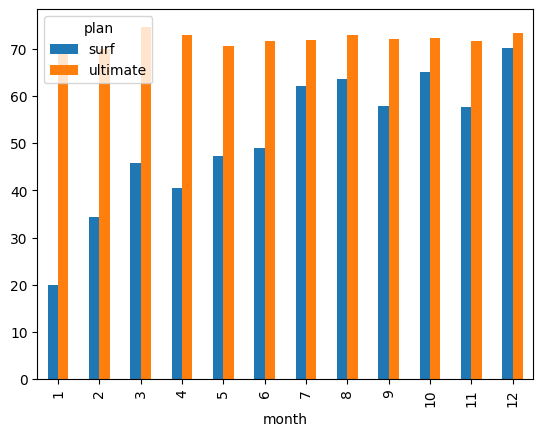

In [47]:
df_monthly.groupby(['month','plan'])['total_ingresos'].mean().unstack().plot(kind='bar')


se puede observar que el plan Ultimate generó más ingresos durante casi todo el año, excepto en el mes de diciembre, los ingresos del plan Surf y Ultimate fueron casi iguales.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Excelente trabajo con las visualizaciones de datos. Además, calculaste correctamente la información estadística de cada distribución de datos, tanto para el consumo de minutos, mensajes e internet, como para los ingresos asociados a los cobros mensuales en cada plan. Esto permite identificar patrones de comportamiento en los usuarios y extraer información valiosa para la compañía.

</div>

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [51]:
# Prueba las hipótesis

df_surf= df_monthly[df_monthly['plan']== 'surf']
df_ultimate= df_monthly[df_monthly['plan']== 'ultimate']

alpha = 0.05 
results = st.ttest_ind(df_surf['total_ingresos'], df_ultimate['total_ingresos'])

print('valor p:',results.pvalue) 

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")



valor p: 9.342071816297584e-09
Rechazamos la hipótesis nula


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [56]:
# Prueba las hipótesis

df_city=df_monthly[df_monthly['city']=='New York-Newark-Jersey City, NY-NJ-PA MSA']
df_city2=df_monthly[df_monthly['city']!='New York-Newark-Jersey City, NY-NJ-PA MSA']

alpha = 0.05

results = st.ttest_ind(df_city['total_ingresos'],df_city2['total_ingresos'])

print('valor p:',results.pvalue) 

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")





valor p: 0.04073944362703164
Rechazamos la hipótesis nula


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Franshelly aplicaste correctamente las pruebas de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de  [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la prueba t sea estadísticamente válida.

</div>
</div>

## Conclusión general

al llamar mis 5 data frames, podemos observar que contiene datos de tipo enteros, flotantes y valores nulos, Las columnas de fecha estában como tipo object, por lo que se convertieron  a tipo fecha con el metodo pd.to_datetime(). de igual manera se agrego la columna de month con el parametro dt. para enriquecer los datos.


para la segunda parte del proyecto se utilizo el metodo groupby() para agrupar las columnas necesarias para sacar el comporamiento de uso de los diferrentes servicios (llamadas, internet, mensajes) de los usuarios. 

para la parte final del proyecto se fuciono todos los datos en un solo date frame usando el metodo merge() para luego representar el comportamiento de los usuarios en  distintos tipos de grafica barras, caja e histogramas con el metodo plot() y finalmente se hizo una prueba de hipotesis con metodo st.ttest_ind().
    



<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Aunque en tu conclusión presentas una visión general del trabajo desarrollado, te enfocas más en lo que hiciste pero no tanto en la información que obtuviste, estoy seguro que tus conclusiones pueden ser más profundas y útiles para el caso de estudio. Ten en cuenta que has realizado un estudio muy detallado de la información del dataset, por lo que puedes presentar perspectivas que sean claves para la toma de decisiones. Te animo a profundizar más en tus interpretaciones y a relacionar tus hallazgos con los objetivos del negocio.

</div>